In [35]:
# AIMONK MULTILABEL TRAINING CODE
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt

In [36]:
# Path Settings
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
import os
BASE_PATH = "/content/drive/MyDrive/Dataset"

IMAGE_DIR = "/content/drive/MyDrive/Dataset/images/images"
LABEL_FILE = "/content/drive/MyDrive/Dataset/labels.txt"

print("Images Path:", IMAGE_DIR)
print("Label File:", LABEL_FILE)
print("Total Images:", len(os.listdir(IMAGE_DIR)))

Images Path: /content/drive/MyDrive/Dataset/images/images
Label File: /content/drive/MyDrive/Dataset/labels.txt
Total Images: 972


In [39]:
from torch.utils.data import Dataset
from PIL import Image
import os
import numpy as np

class SafeDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform

        # Keep only images that actually exist
        self.samples = []
        for _, row in df.iterrows():
            img_path = os.path.join(img_dir, row["Image Name"])
            if os.path.exists(img_path):   # <-- KEY FIX
                self.samples.append((img_path, row))

        print("Usable images:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, row = self.samples[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        labels = row[["Attr1","Attr2","Attr3","Attr4"]].values.astype(np.float32)

        mask = ~np.isnan(labels)   # handle NA
        labels = np.nan_to_num(labels)

        return image, labels, mask.astype(np.float32)

In [40]:
# ========= LOAD LABEL FILE =========
df = pd.read_csv(LABEL_FILE, sep=" ", header=None)
df.columns = ["Image Name","Attr1","Attr2","Attr3","Attr4"]

# Convert NA properly
df = df.replace("NA", np.nan)
for c in ["Attr1","Attr2","Attr3","Attr4"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")


In [41]:
# ========= SAFE DATASET =========
class SafeDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.samples = []
        self.transform = transform

        for _, row in df.iterrows():
            path = os.path.join(img_dir, row["Image Name"])
            if os.path.exists(path):  # skip missing images safely
                self.samples.append((path, row))

        print("Total usable images:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, row = self.samples[idx]

        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        labels = row[["Attr1","Attr2","Attr3","Attr4"]].values.astype(np.float32)

        mask = ~np.isnan(labels)      # NA handling
        labels = np.nan_to_num(labels)

        return image, labels, mask.astype(np.float32)


In [42]:
# ========= TRANSFORMS (FAST) =========
transform = transforms.Compose([
    transforms.Resize((160,160)),
    transforms.ToTensor()
])

dataset = SafeDataset(df, IMAGE_DIR, transform)
loader = DataLoader(dataset, batch_size=32, shuffle=True)


Total usable images: 972


In [43]:
# ========= MODEL (PRETRAINED) =========
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = models.mobilenet_v2(weights="IMAGENET1K_V1")
model.classifier[1] = nn.Linear(model.last_channel, 4)
model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 205MB/s]


In [44]:
# ========= HANDLE IMBALANCE =========
label_counts = df[["Attr1","Attr2","Attr3","Attr4"]].fillna(0)
pos_weights = (len(label_counts) - label_counts.sum()) / (label_counts.sum()+1e-5)
pos_weights = torch.tensor(pos_weights.values, dtype=torch.float32).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(reduction='none', pos_weight=pos_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [45]:
# ========= TRAIN LOOP =========
EPOCHS = 3
loss_curve = []
iteration = 0

model.train()
for epoch in range(EPOCHS):
    for images, labels, mask in loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        mask = mask.to(DEVICE)

        outputs = model(images)

        loss = criterion(outputs, labels)
        loss = (loss * mask).sum() / mask.sum()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_curve.append(loss.item())
        iteration += 1

        if iteration % 10 == 0:
            print(f"Iter {iteration} Loss {loss.item():.4f}")


Iter 10 Loss 0.7507
Iter 20 Loss 0.8323
Iter 30 Loss 0.6865
Iter 40 Loss 0.4885
Iter 50 Loss 0.5022
Iter 60 Loss 0.5836
Iter 70 Loss 0.4635
Iter 80 Loss 0.3955
Iter 90 Loss 0.4003


In [46]:
# ========= SAVE MODEL =========
torch.save(model.state_dict(), "aimonk_model.pth")
print("Model Saved!")


Model Saved!


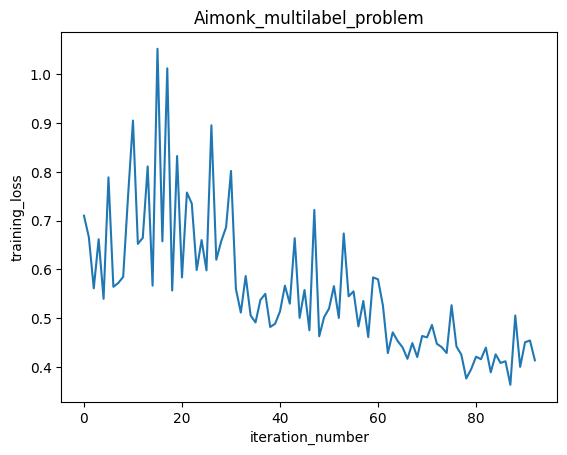

Training Completed!


In [47]:
# ========= PLOT LOSS CURVE =========
plt.plot(loss_curve)
plt.ylabel("training_loss")
plt.xlabel("iteration_number")
plt.title("Aimonk_multilabel_problem")
plt.savefig("loss_curve.png")
plt.show()

print("Training Completed!")

In [54]:
# ======================
# AIMONK INFERENCE CODE
# ======================

import torch
from torchvision import transforms, models
from PIL import Image
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = models.mobilenet_v2(weights=None)
model.classifier[1] = torch.nn.Linear(model.last_channel, 4)
model.load_state_dict(torch.load("aimonk_model.pth", map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

transform = transforms.Compose([
    transforms.Resize((160,160)),
    transforms.ToTensor()
])

def predict(image_path):
    img = Image.open(image_path).convert("RGB")
    img = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = torch.sigmoid(model(img)).cpu().numpy()[0]

    attrs = ["Attr1","Attr2","Attr3","Attr4"]
    for name, prob in zip(attrs, output):
      print(f"{name}: {prob:.3f}")
      present = [attrs[i] for i,v in enumerate(output) if v>0.5]
      print("\nPredicted Attributes:", present)

# Example
predict(os.path.join(IMAGE_DIR, "image_350.jpg"))
predict(os.path.join(IMAGE_DIR, "image_10.jpg"))
predict(os.path.join(IMAGE_DIR, "image_25.jpg"))
predict(os.path.join(IMAGE_DIR, "image_80.jpg"))

Attr1: 0.598

Predicted Attributes: ['Attr1', 'Attr2', 'Attr3', 'Attr4']
Attr2: 0.681

Predicted Attributes: ['Attr1', 'Attr2', 'Attr3', 'Attr4']
Attr3: 0.593

Predicted Attributes: ['Attr1', 'Attr2', 'Attr3', 'Attr4']
Attr4: 0.963

Predicted Attributes: ['Attr1', 'Attr2', 'Attr3', 'Attr4']
Attr1: 0.665

Predicted Attributes: ['Attr1', 'Attr2']
Attr2: 0.704

Predicted Attributes: ['Attr1', 'Attr2']
Attr3: 0.495

Predicted Attributes: ['Attr1', 'Attr2']
Attr4: 0.330

Predicted Attributes: ['Attr1', 'Attr2']
Attr1: 0.624

Predicted Attributes: ['Attr1', 'Attr2']
Attr2: 0.655

Predicted Attributes: ['Attr1', 'Attr2']
Attr3: 0.493

Predicted Attributes: ['Attr1', 'Attr2']
Attr4: 0.449

Predicted Attributes: ['Attr1', 'Attr2']
Attr1: 0.662

Predicted Attributes: ['Attr1', 'Attr2', 'Attr3']
Attr2: 0.610

Predicted Attributes: ['Attr1', 'Attr2', 'Attr3']
Attr3: 0.663

Predicted Attributes: ['Attr1', 'Attr2', 'Attr3']
Attr4: 0.298

Predicted Attributes: ['Attr1', 'Attr2', 'Attr3']
